# Análisis Exploratorio de Datos (EDA) y Modelo de Predicción ARIMA_PLUS
## Sector Agrícola del Valle del Cauca (2000 - 2027)

Este notebook presenta la metodología completa de análisis agrícola y ciencia de datos sobre la base consolidada `silver_agri_modelo_base`:
1. **EDA Nivel 1: Por Cultivo**: Volumen de producción acumulada, hectáreas sembradas, rendimientos y variabilidad.
2. **EDA Nivel 2: Por Municipio**: Producción agrícola total, diversidad de cultivos y densidad productiva.
3. **EDA Nivel 3: Por Municipio y Cultivo con Análisis de Correlación**: Interrelaciones intervariables (Hectáreas, Producción, Rendimiento, Precios SIPSA e Índice Climático ONI).
4. **Esquema de Predicción ARIMA_PLUS**: Selección de hiperparámetros $(p, d, q)$, estacionariedad y tendencia por serie temporal.
5. **Backtesting & Evaluación de Desempeño**: Medición del coeficiente de determinación $R^2$, RMSE, MAE y MAPE en muestras fuera de tiempo (2022-2024), identificando las series con $R^2 \ge 0.7$.
6. **Pronóstico a 3 Años (2025 - 2027)**: Proyecciones futuras de producción con intervalos de confianza al 80%.

In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

# Función auxiliar para resolver rutas de datos e imágenes en cualquier entorno de ejecución
def get_path(rel_path):
    p = Path(rel_path)
    if p.exists():
        return p
    p_sub = Path('../') / rel_path
    if p_sub.exists():
        return p_sub
    return p

# Cargar archivos de datos de resumen del modelo agrícola
df_cultivo = pd.read_csv(get_path('data/eda_resumen_por_cultivo.csv'))
df_mun = pd.read_csv(get_path('data/eda_resumen_por_municipio.csv'))
df_corr_pearson = pd.read_csv(get_path('data/matriz_correlacion_pearson.csv'), index_col=0)
df_eval = pd.read_csv(get_path('data/evaluacion_modelos_arima.csv'))
df_fc = pd.read_csv(get_path('data/predicciones_3_anos_r2_optimo.csv'))

print("--- Resumen de Datasets de Análisis y Pronóstico Cargados ---")
print(f"Cultivos analizados: {len(df_cultivo)} | Municipios analizados: {len(df_mun)}")
print(f"Modelos ARIMA evaluados: {len(df_eval)} | Series con R² >= 0.7: {(df_eval['cumple_r2_07'] == True).sum()}")

--- Resumen de Datasets de Análisis y Pronóstico Cargados ---
Cultivos analizados: 104 | Municipios analizados: 42
Modelos ARIMA evaluados: 806 | Series con R² >= 0.7: 143


---
## 1. EDA por Cultivo

Análisis agrupado por tipo de cultivo en el departamento del Valle del Cauca, identificando los rubros de mayor producción y rendimiento agrícola.

=== TODOS LOS CULTIVOS POR PRODUCCIÓN ACUMULADA (TONELADAS) ===


,cultivo,total_produccion,rendimiento_promedio,total_ha_sembradas,coef_variacion_prod_pct
0,Caña De Azúcar,5.038293e+08,113.904521,4763449.81,116.889931
1,Caña Panelera,7.687995e+06,54.076587,144538.36,159.770329
2,Plátano,5.355779e+06,10.058824,574797.57,187.560998
3,Cítricos,2.557539e+06,18.714883,118354.54,223.453191
4,Piña,2.346291e+06,58.678474,43927.90,195.817189
...,...,...,...,...,...
99,Arazá,2.580000e+01,0.701000,36.00,47.110698
100,Maní,2.430000e+01,1.666667,12.30,83.395039
101,Anturios,6.000000e+00,6.000000,1.00,NaN
102,Cartuchos,5.000000e+00,5.000000,1.00,NaN


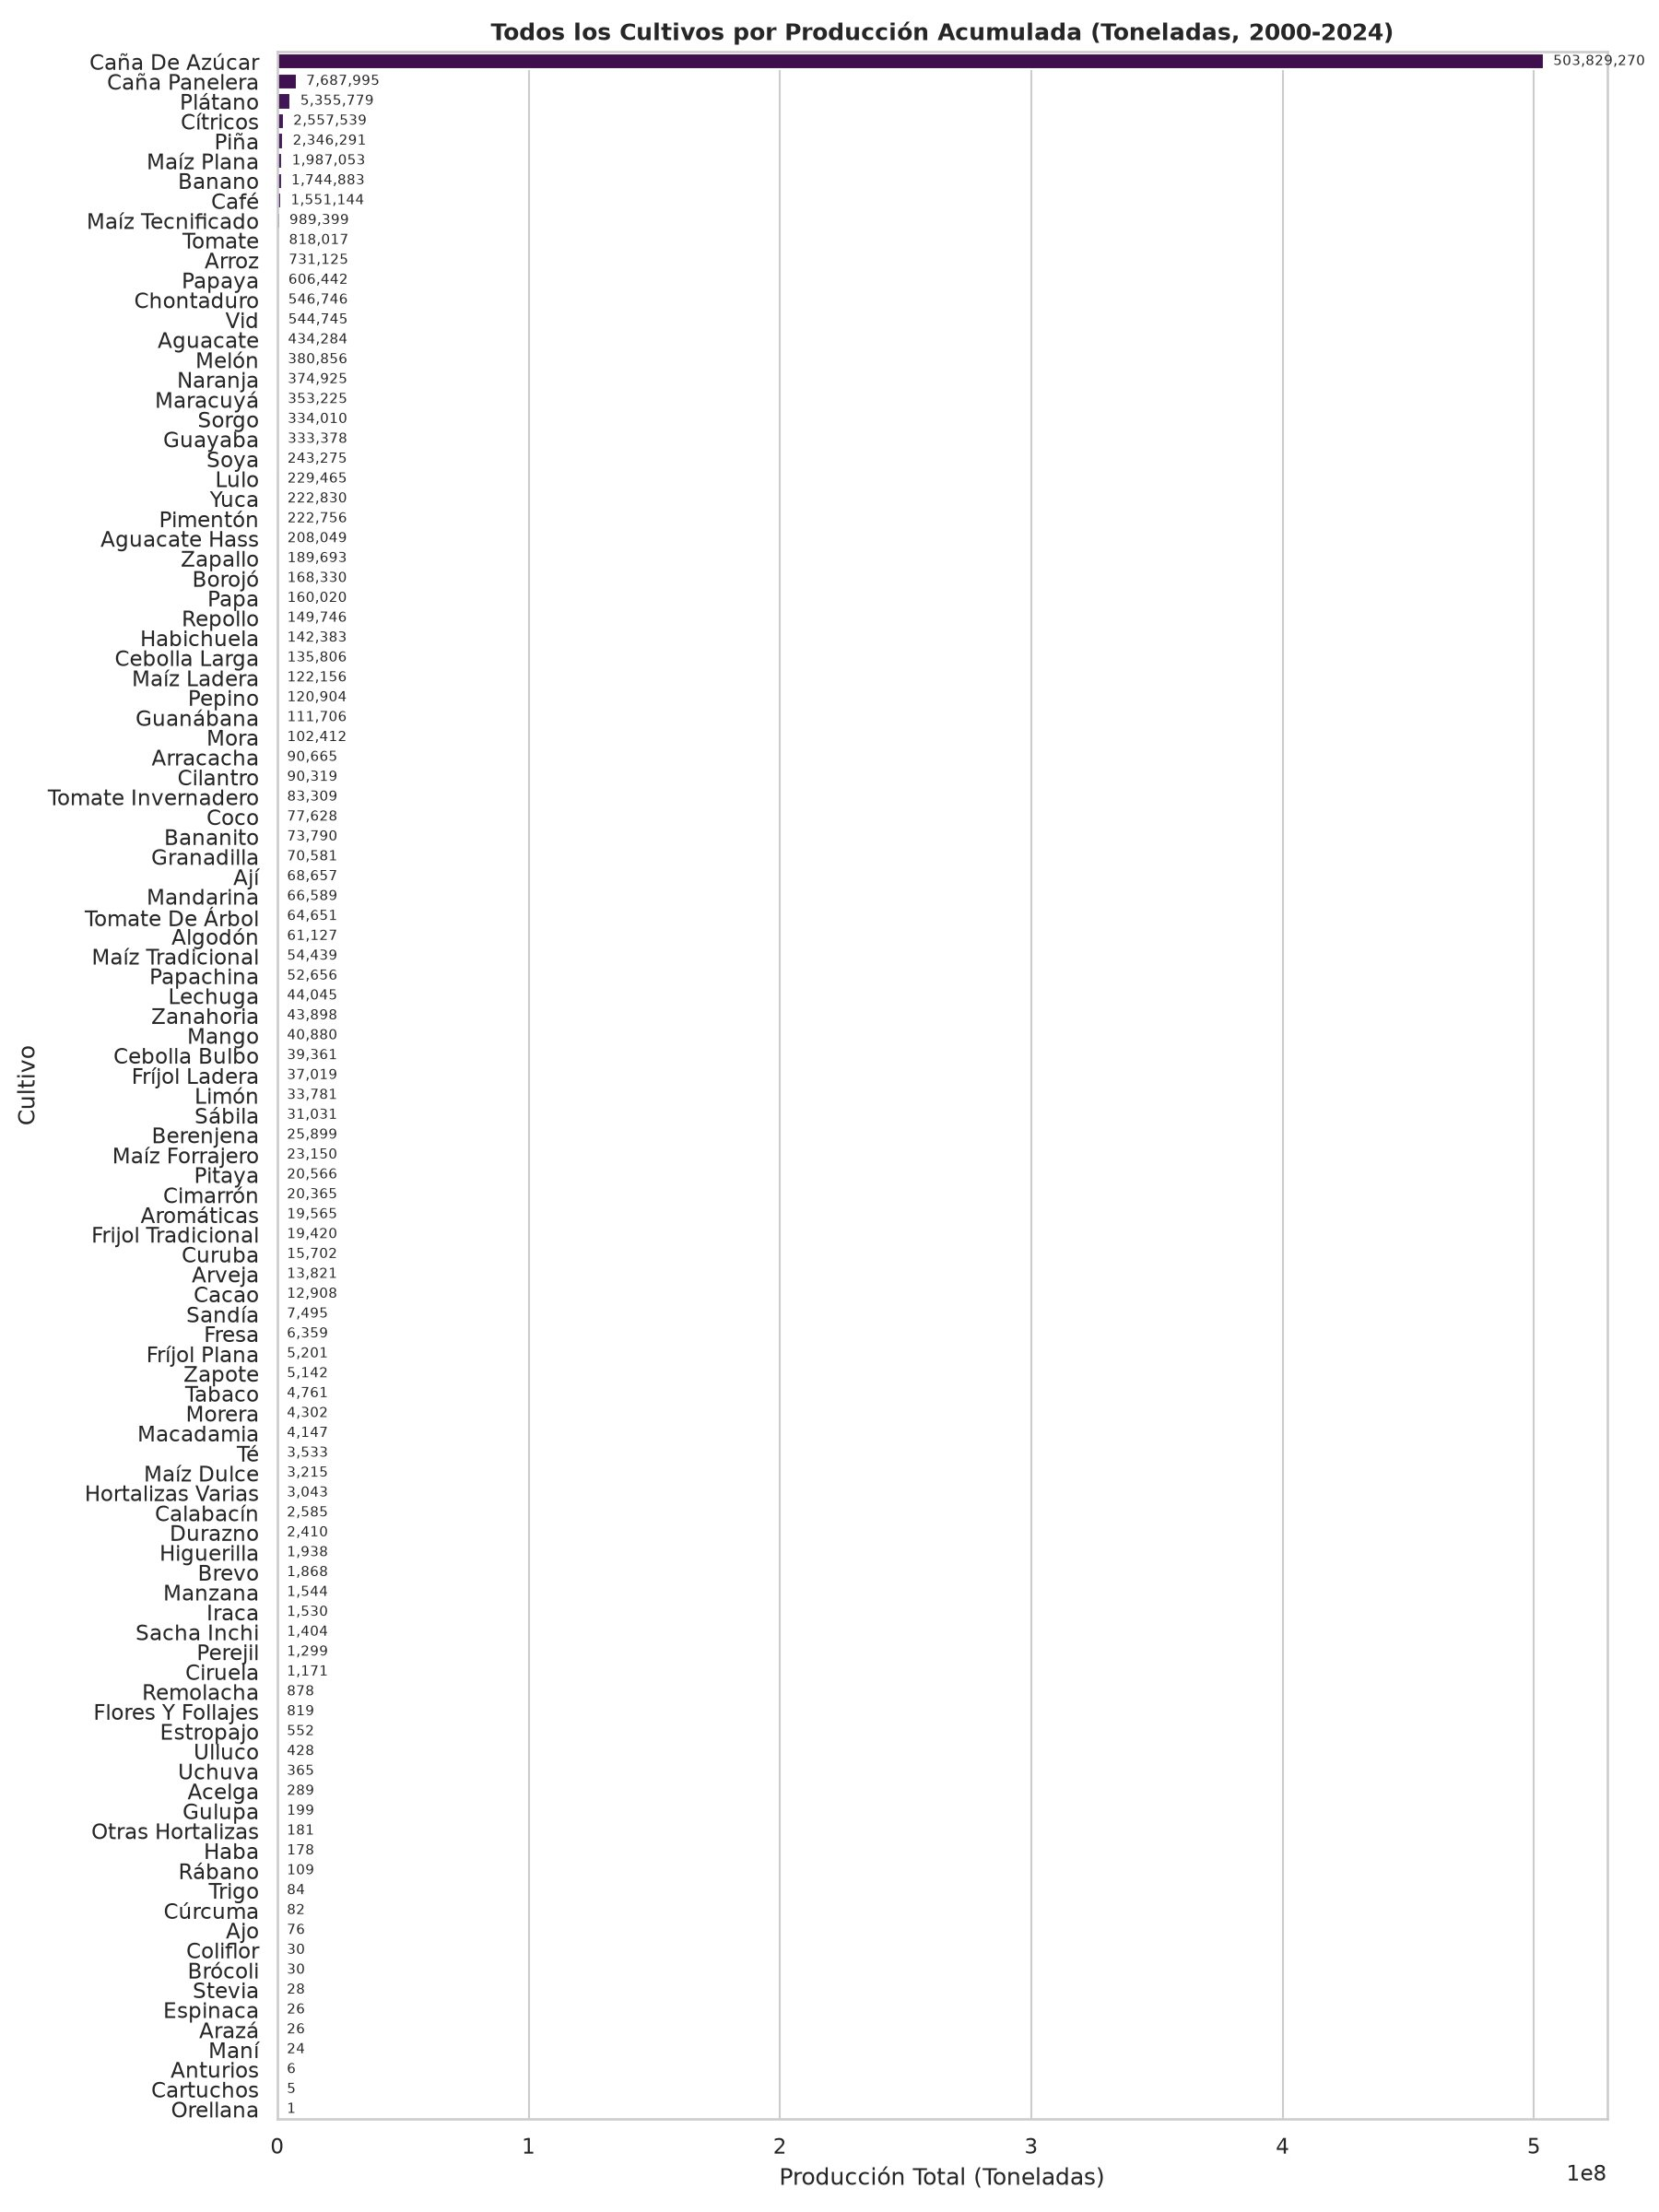

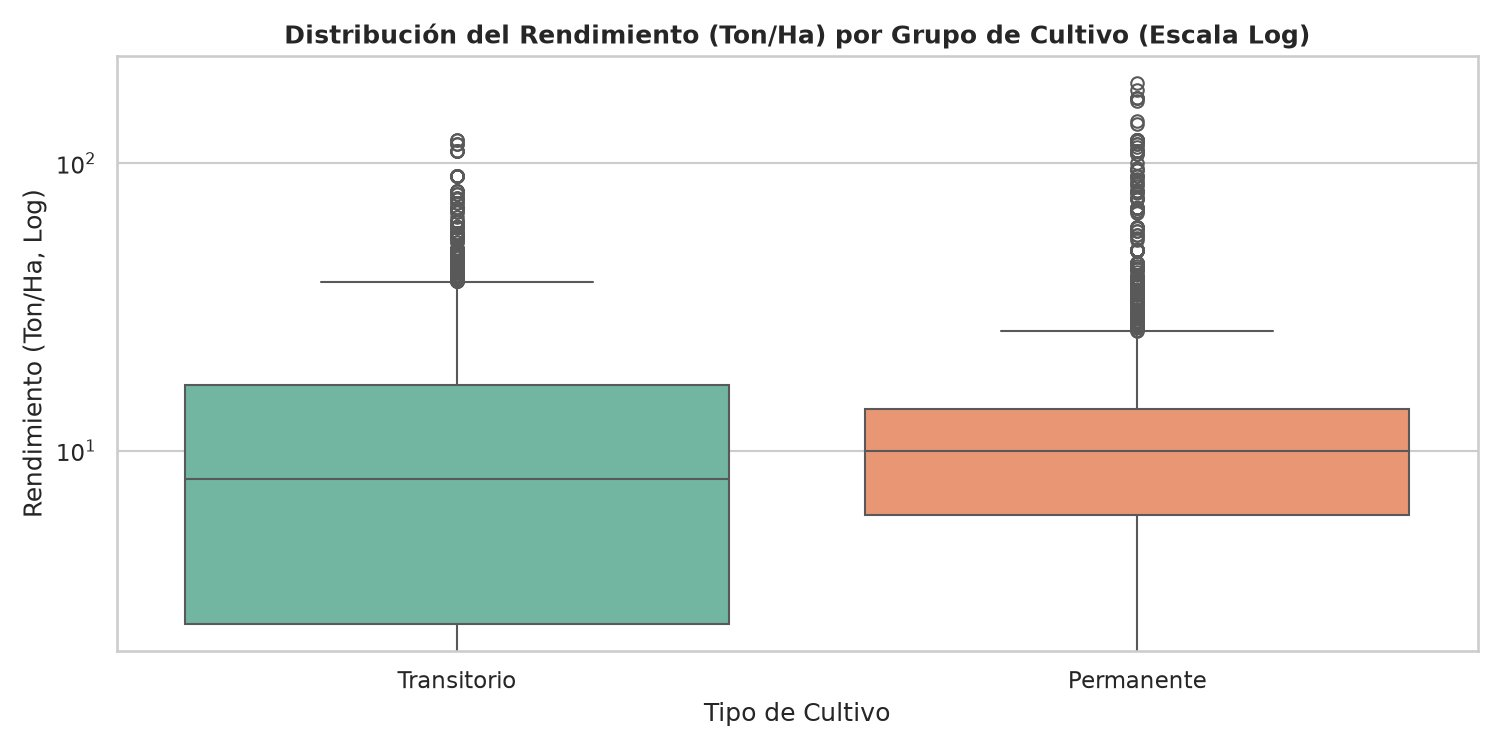

In [2]:
print("=== TODOS LOS CULTIVOS POR PRODUCCIÓN ACUMULADA (TONELADAS) ===")
display(df_cultivo[['cultivo', 'total_produccion', 'rendimiento_promedio', 'total_ha_sembradas', 'coef_variacion_prod_pct']])

img1 = get_path('notebooks/figures/eda_cultivo_top15_produccion.png')
if not img1.exists():
    img1 = get_path('figures/eda_cultivo_top15_produccion.png')
if img1.exists():
    display(Image(filename=str(img1)))

img2 = get_path('notebooks/figures/eda_cultivo_rendimiento_por_grupo.png')
if not img2.exists():
    img2 = get_path('figures/eda_cultivo_rendimiento_por_grupo.png')
if img2.exists():
    display(Image(filename=str(img2)))

---
## 2. EDA por Municipio

Análisis territorial de producción agrícola total, diversidad de cultivos producidos y hectáreas cultivadas por municipio.

=== TODOS LOS MUNICIPIOS POR PRODUCCIÓN AGRÍCOLA TOTAL ===


,municipio,total_produccion,diversidad_cultivos,total_ha_sembradas
0,Palmira,93805092.25,58,849906.88
1,Cartago,60813012.80,28,605126.18
2,El Cerrito,40142518.25,37,416522.90
3,Guacarí,36026301.26,51,357078.33
4,Zarzal,33191138.90,34,433296.67
5,Florida,30010288.33,55,298120.98
6,Bugalagrande,28622831.25,40,366631.44
7,Pradera,27932489.29,42,283495.20
8,Tuluá,23486460.26,54,448065.33
9,Buga,17883981.61,69,241438.42


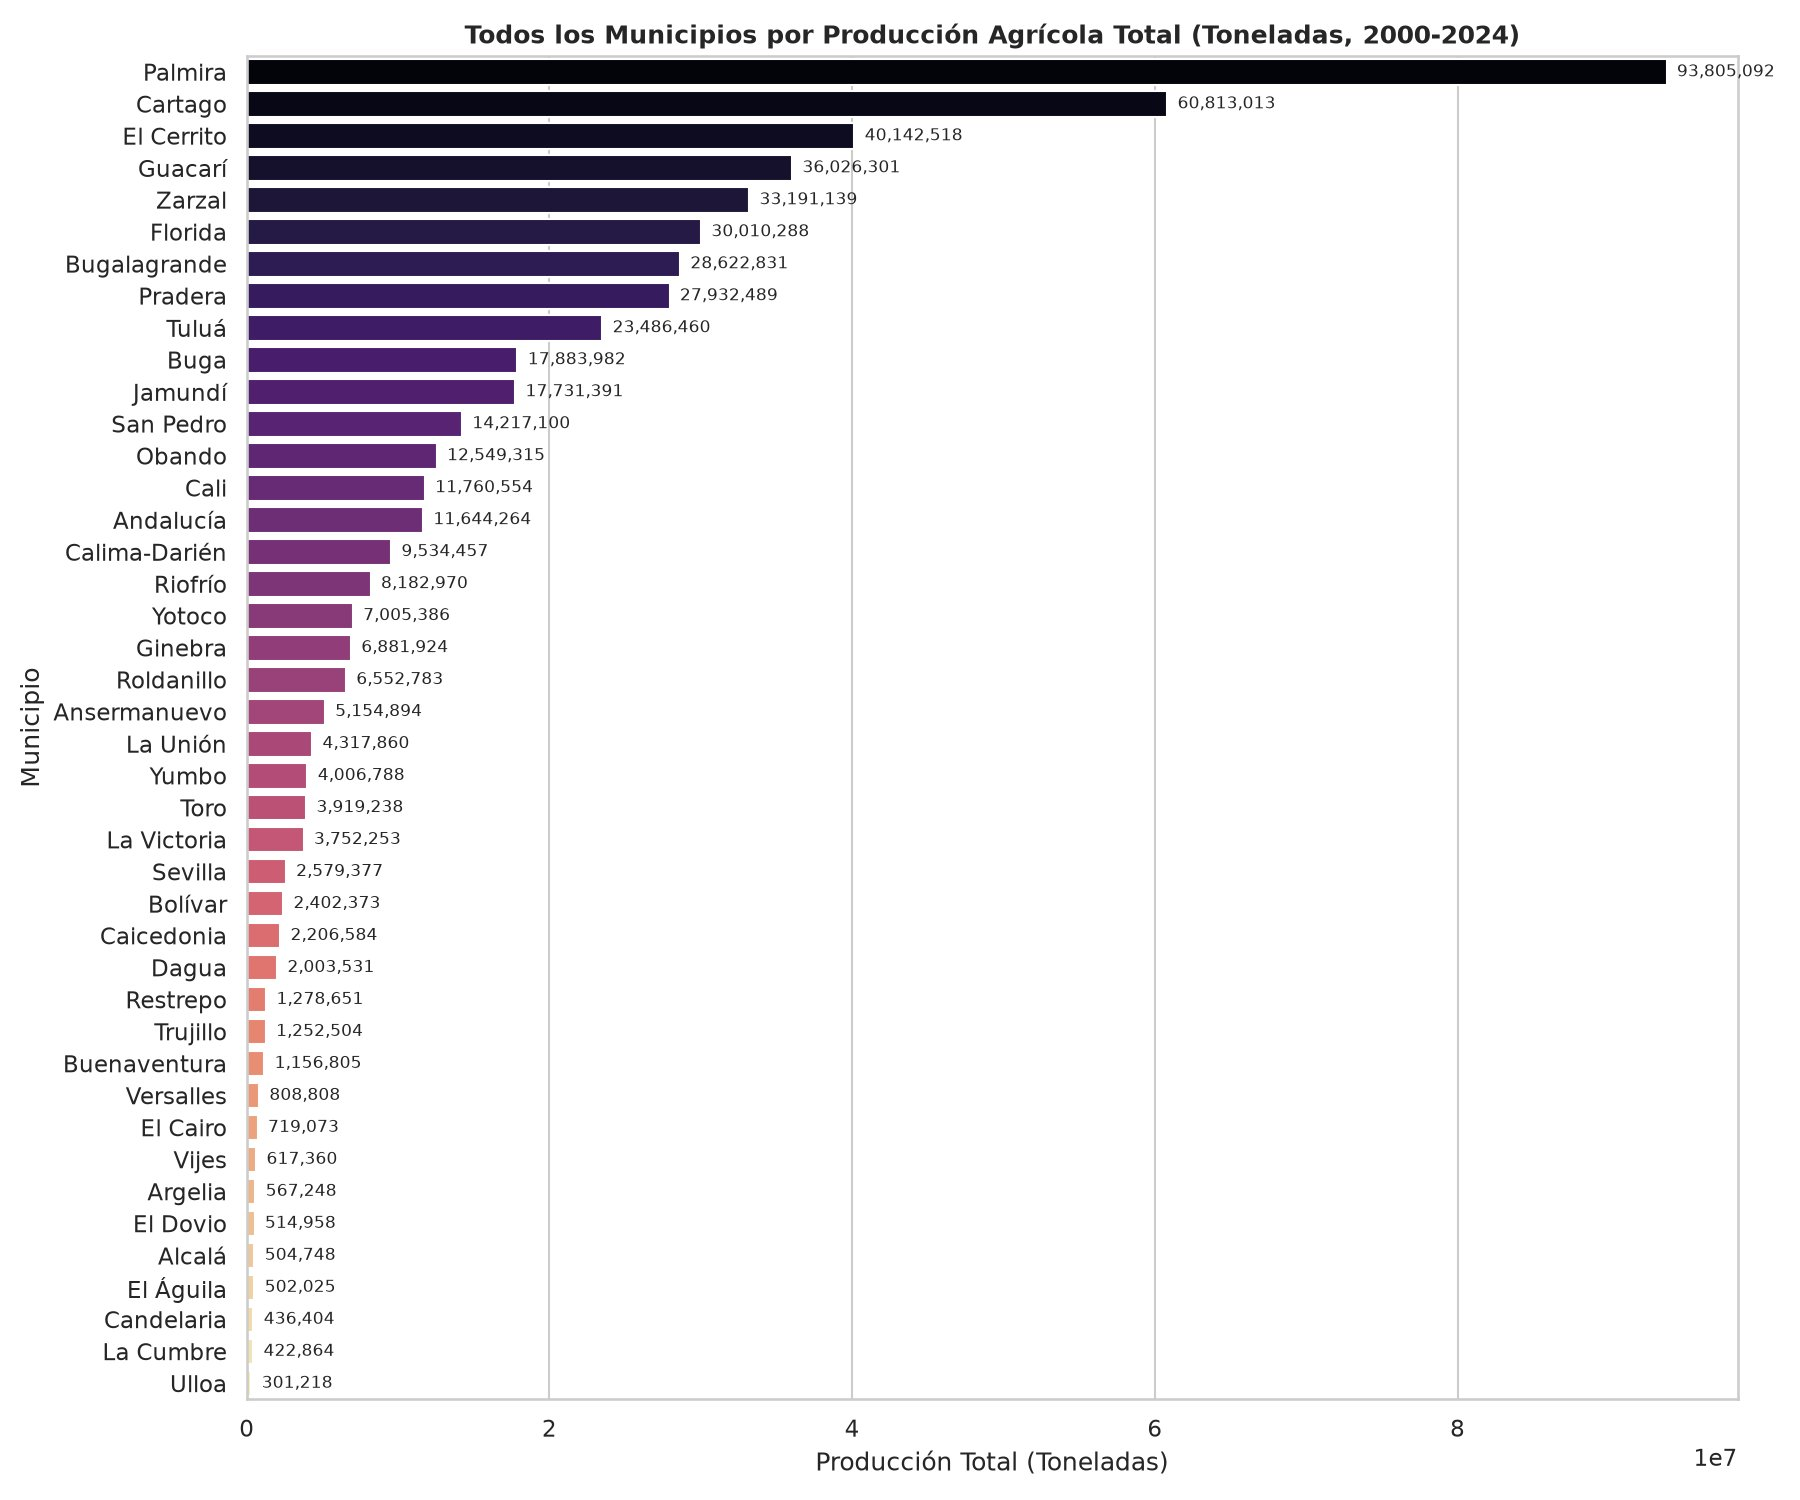

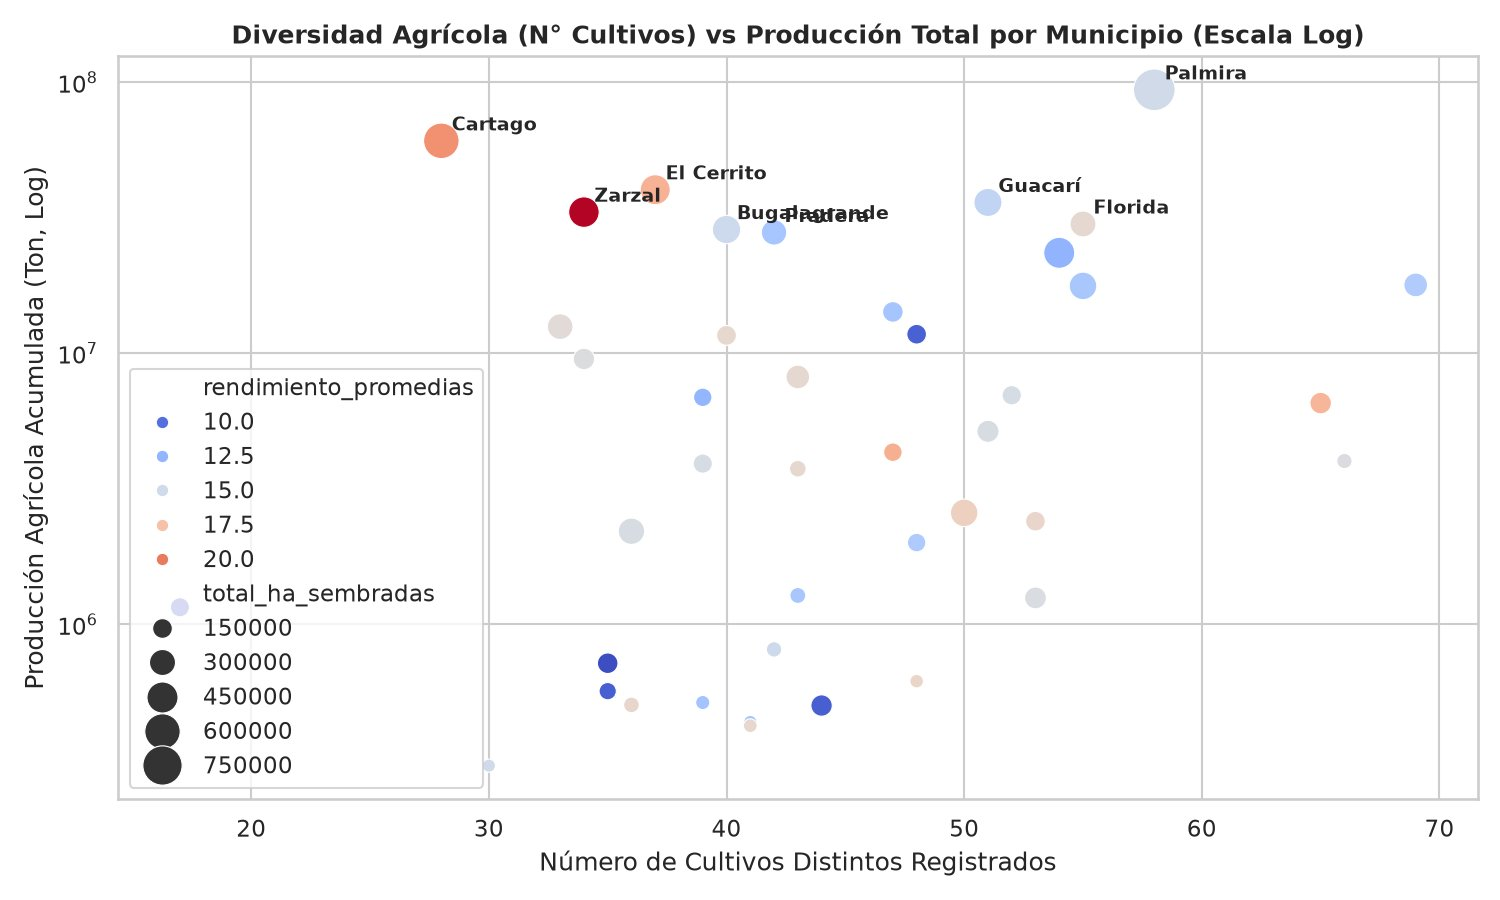

In [3]:
print("=== TODOS LOS MUNICIPIOS POR PRODUCCIÓN AGRÍCOLA TOTAL ===")
display(df_mun[['municipio', 'total_produccion', 'diversidad_cultivos', 'total_ha_sembradas']])

img1 = get_path('notebooks/figures/eda_municipio_top15_produccion.png')
if not img1.exists():
    img1 = get_path('figures/eda_municipio_top15_produccion.png')
if img1.exists():
    display(Image(filename=str(img1)))

img2 = get_path('notebooks/figures/eda_municipio_diversidad_vs_produccion.png')
if not img2.exists():
    img2 = get_path('figures/eda_municipio_diversidad_vs_produccion.png')
if img2.exists():
    display(Image(filename=str(img2)))

---
## 3. EDA por Municipio, Cultivo y Matriz de Correlación

Análisis de correlación multivariable entre hectáreas sembradas, cosechadas, volumen de producción, rendimientos (Ton/Ha), precios SIPSA e índice climático ONI.

=== MATRIZ DE CORRELACIÓN DE PEARSON (VARIABLES CLAVE) ===


,hectareas_sembradas,hectareas_cosechadas,produccion_toneladas,rendimiento_toneladas_ha,precio_promedio_anual_sipsa,promedio_oni
hectareas_sembradas,1.000,0.989,0.928,0.455,-0.035,-0.001
hectareas_cosechadas,0.989,1.000,0.938,0.449,-0.048,-0.000
produccion_toneladas,0.928,0.938,1.000,0.510,-0.117,0.000
rendimiento_toneladas_ha,0.455,0.449,0.510,1.000,-0.239,0.012
precio_promedio_anual_sipsa,-0.035,-0.048,-0.117,-0.239,1.000,-0.161
promedio_oni,-0.001,-0.000,0.000,0.012,-0.161,1.000


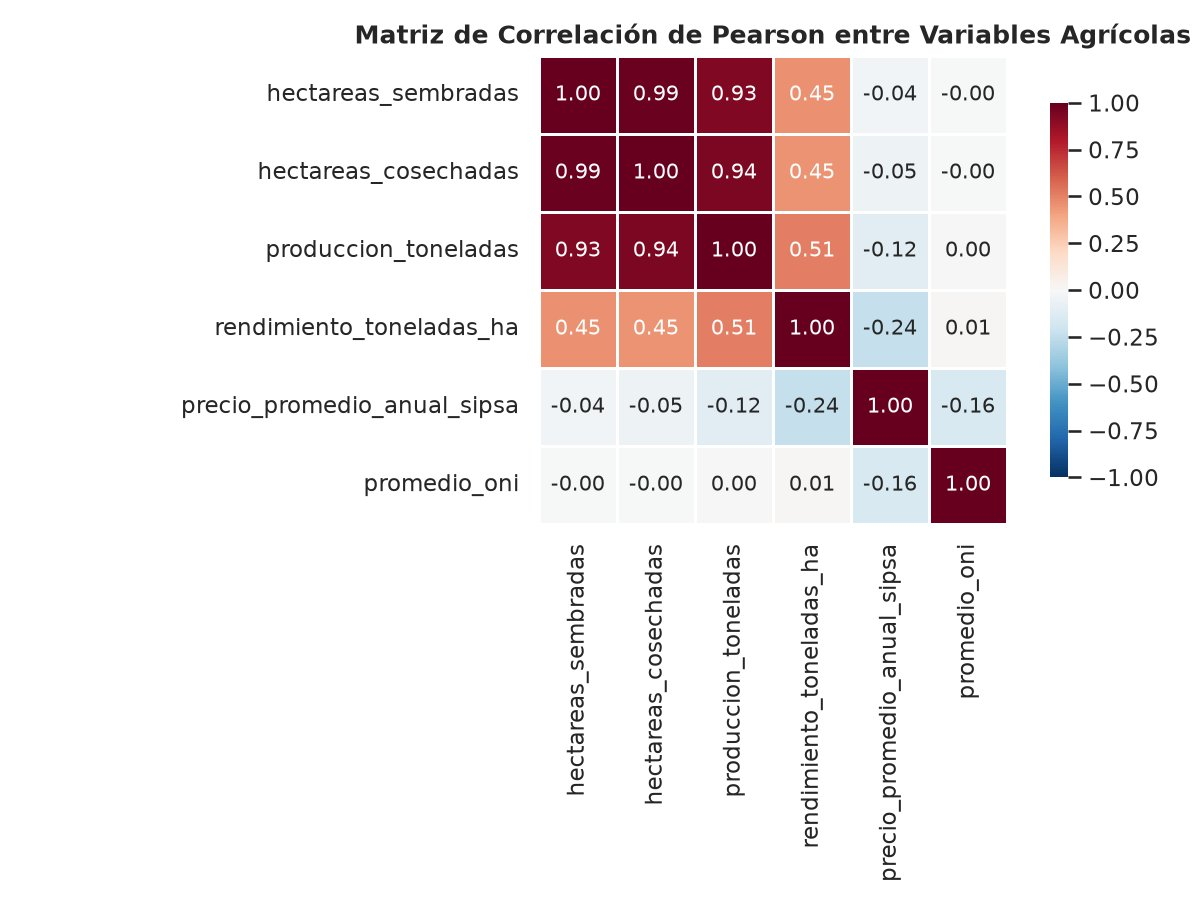

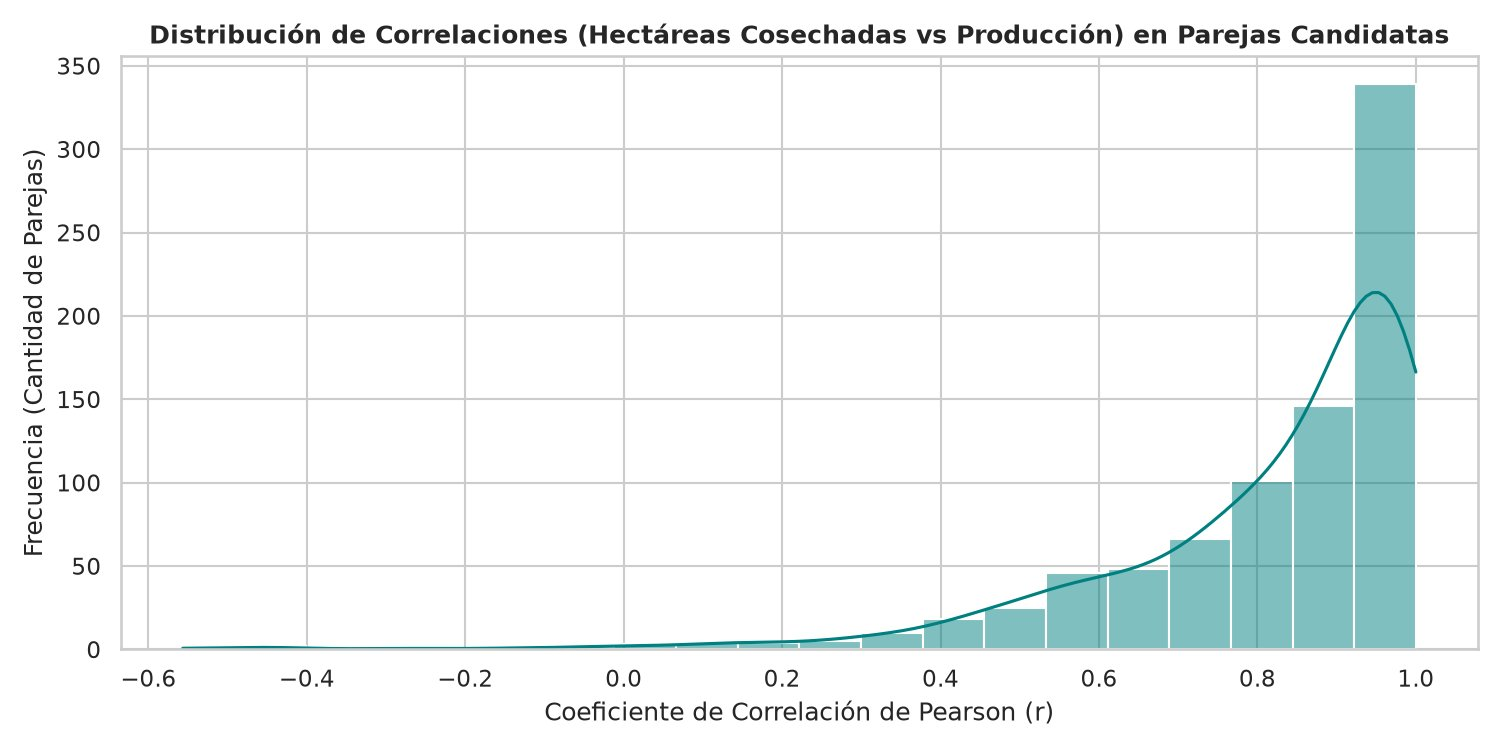

In [4]:
print("=== MATRIZ DE CORRELACIÓN DE PEARSON (VARIABLES CLAVE) ===")
display(df_corr_pearson.round(3))

img1 = get_path('notebooks/figures/eda_correlacion_pearson_heatmap.png')
if not img1.exists():
    img1 = get_path('figures/eda_correlacion_pearson_heatmap.png')
if img1.exists():
    display(Image(filename=str(img1)))

img2 = get_path('notebooks/figures/eda_distribucion_correlacion_ha_vs_prod.png')
if not img2.exists():
    img2 = get_path('figures/eda_distribucion_correlacion_ha_vs_prod.png')
if img2.exists():
    display(Image(filename=str(img2)))

---
## 4 & 5. Modelo ARIMA_PLUS, Backtesting y Evaluación ($R^2 \ge 0.7$)

Resultados de la validación cruzada out-of-sample (entrenamiento en período histórico y prueba en 2022-2024), evaluando precisión mediante $R^2$, RMSE, MAE y MAPE.

In [5]:
df_optimos = df_eval[df_eval['cumple_r2_07'] == True].sort_values('r2_score', ascending=False)
print(f"Total de series temporales que cumplen criterio R² >= 0.7: {len(df_optimos)} de {len(df_eval)} evaluadas ({len(df_optimos)/len(df_eval)*100:.1f}%)")

if len(df_optimos) > 0:
    print("=== SERIES QUE CUMPLEN CRITERIO R² >= 0.7 ===")
    display(df_optimos[['municipio', 'cultivo', 'arima_order', 'r2_score', 'rmse', 'mape_pct']])
else:
    print("=== TODAS LAS SERIES EVALUADAS ORDENADAS POR R² ===")
    display(df_eval[['municipio', 'cultivo', 'arima_order', 'r2_score', 'rmse', 'mape_pct']])

Total de series temporales que cumplen criterio R² >= 0.7: 143 de 806 evaluadas (17.7%)
=== SERIES QUE CUMPLEN CRITERIO R² >= 0.7 ===


,municipio,cultivo,arima_order,r2_score,rmse,mape_pct
0,El Cerrito,Caña De Azúcar,"ARIMA(0, 1, 0)",1.000000,0.000000,0.000000
1,Bugalagrande,Cítricos,"ARIMA(0, 1, 0)",1.000000,0.000000,0.000000
2,Toro,Banano,"ARIMA(0, 1, 0)",1.000000,0.000000,0.000000
3,Bolívar,Plátano,"ARIMAX(0, 0, 0)+Hectáreas",1.000000,0.013654,0.000219
4,Restrepo,Guayaba,"ARIMAX(2, 0, 1)+Hectáreas",0.999990,0.031951,0.035815
...,...,...,...,...,...,...
138,La Victoria,Soya,"ARIMAX(0, 0, 0)+Hectáreas",0.714080,159.820017,2960.699731
139,El Cairo,Fríjol Ladera,"ARIMAX(0, 1, 0)+Hectáreas",0.710644,4.216398,211.812590
140,Jamundí,Tomate,"ARIMAX(1, 0, 0)+Hectáreas",0.709402,36.627802,30.781347
141,Ginebra,Caña Panelera,"ARIMAX(2, 0, 0)+Hectáreas",0.707357,306.015778,168.796602


---
## 6. Predicción a 3 Años (2025 - 2027)

Proyección de producción agrícola futura a 3 años para las combinaciones (Municipio - Cultivo) con mayor ajuste y capacidad predictiva, incluyendo intervalos de confianza al 80%.

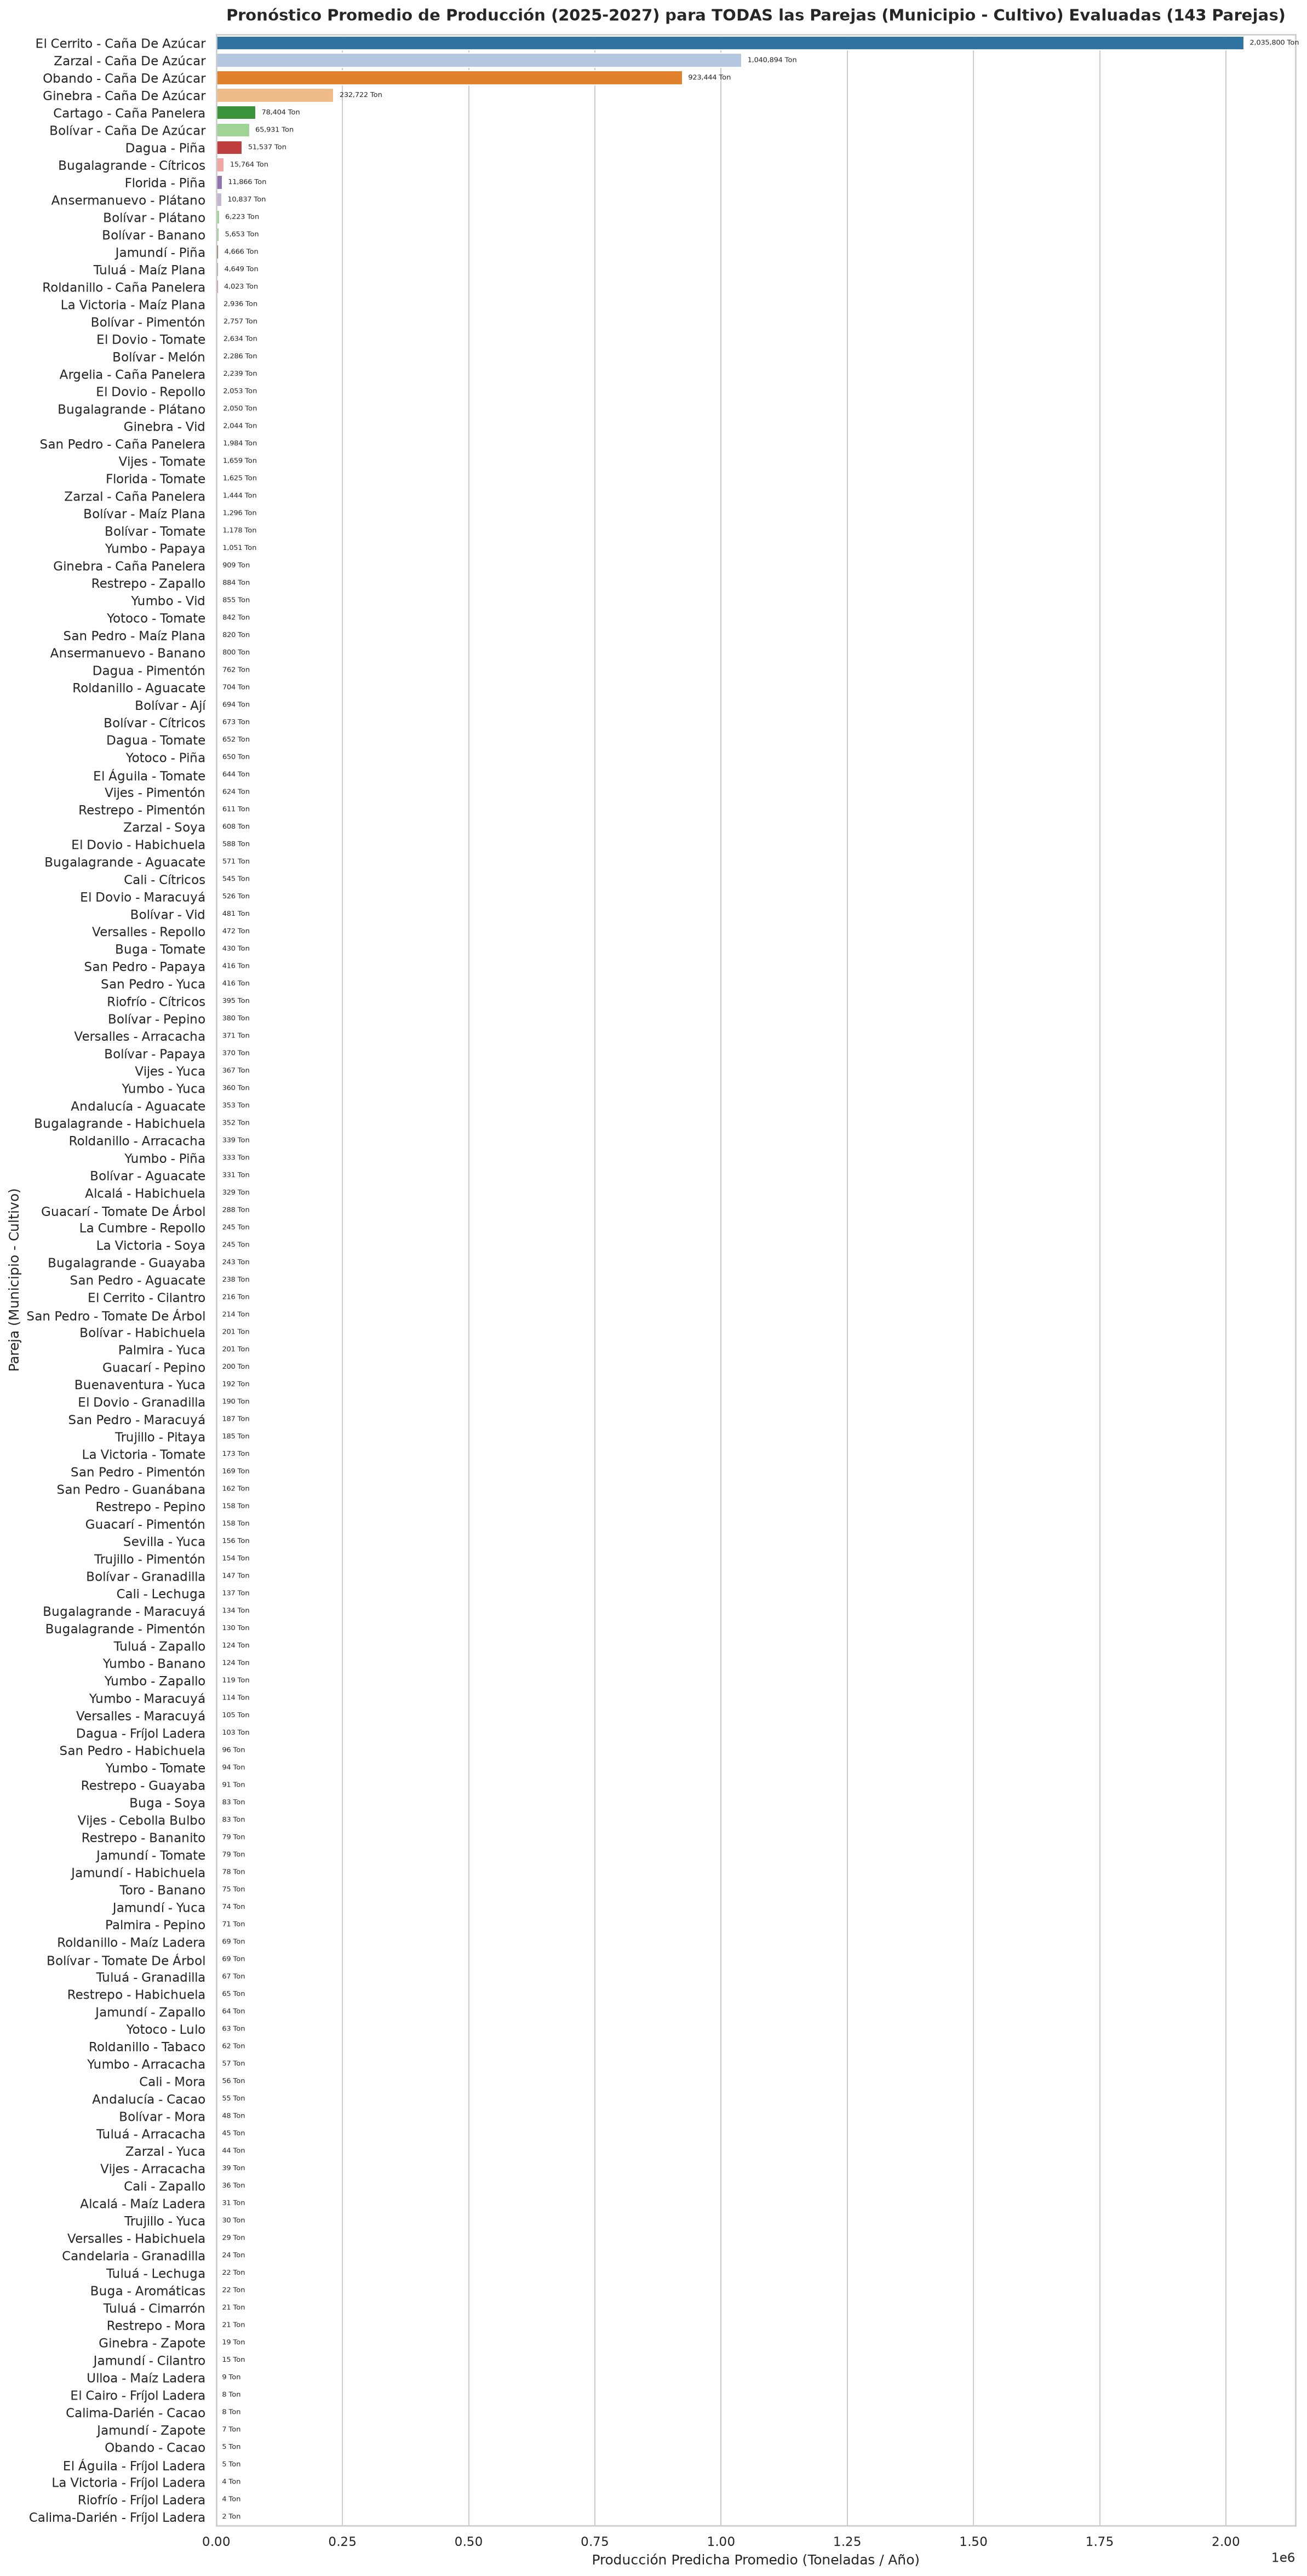

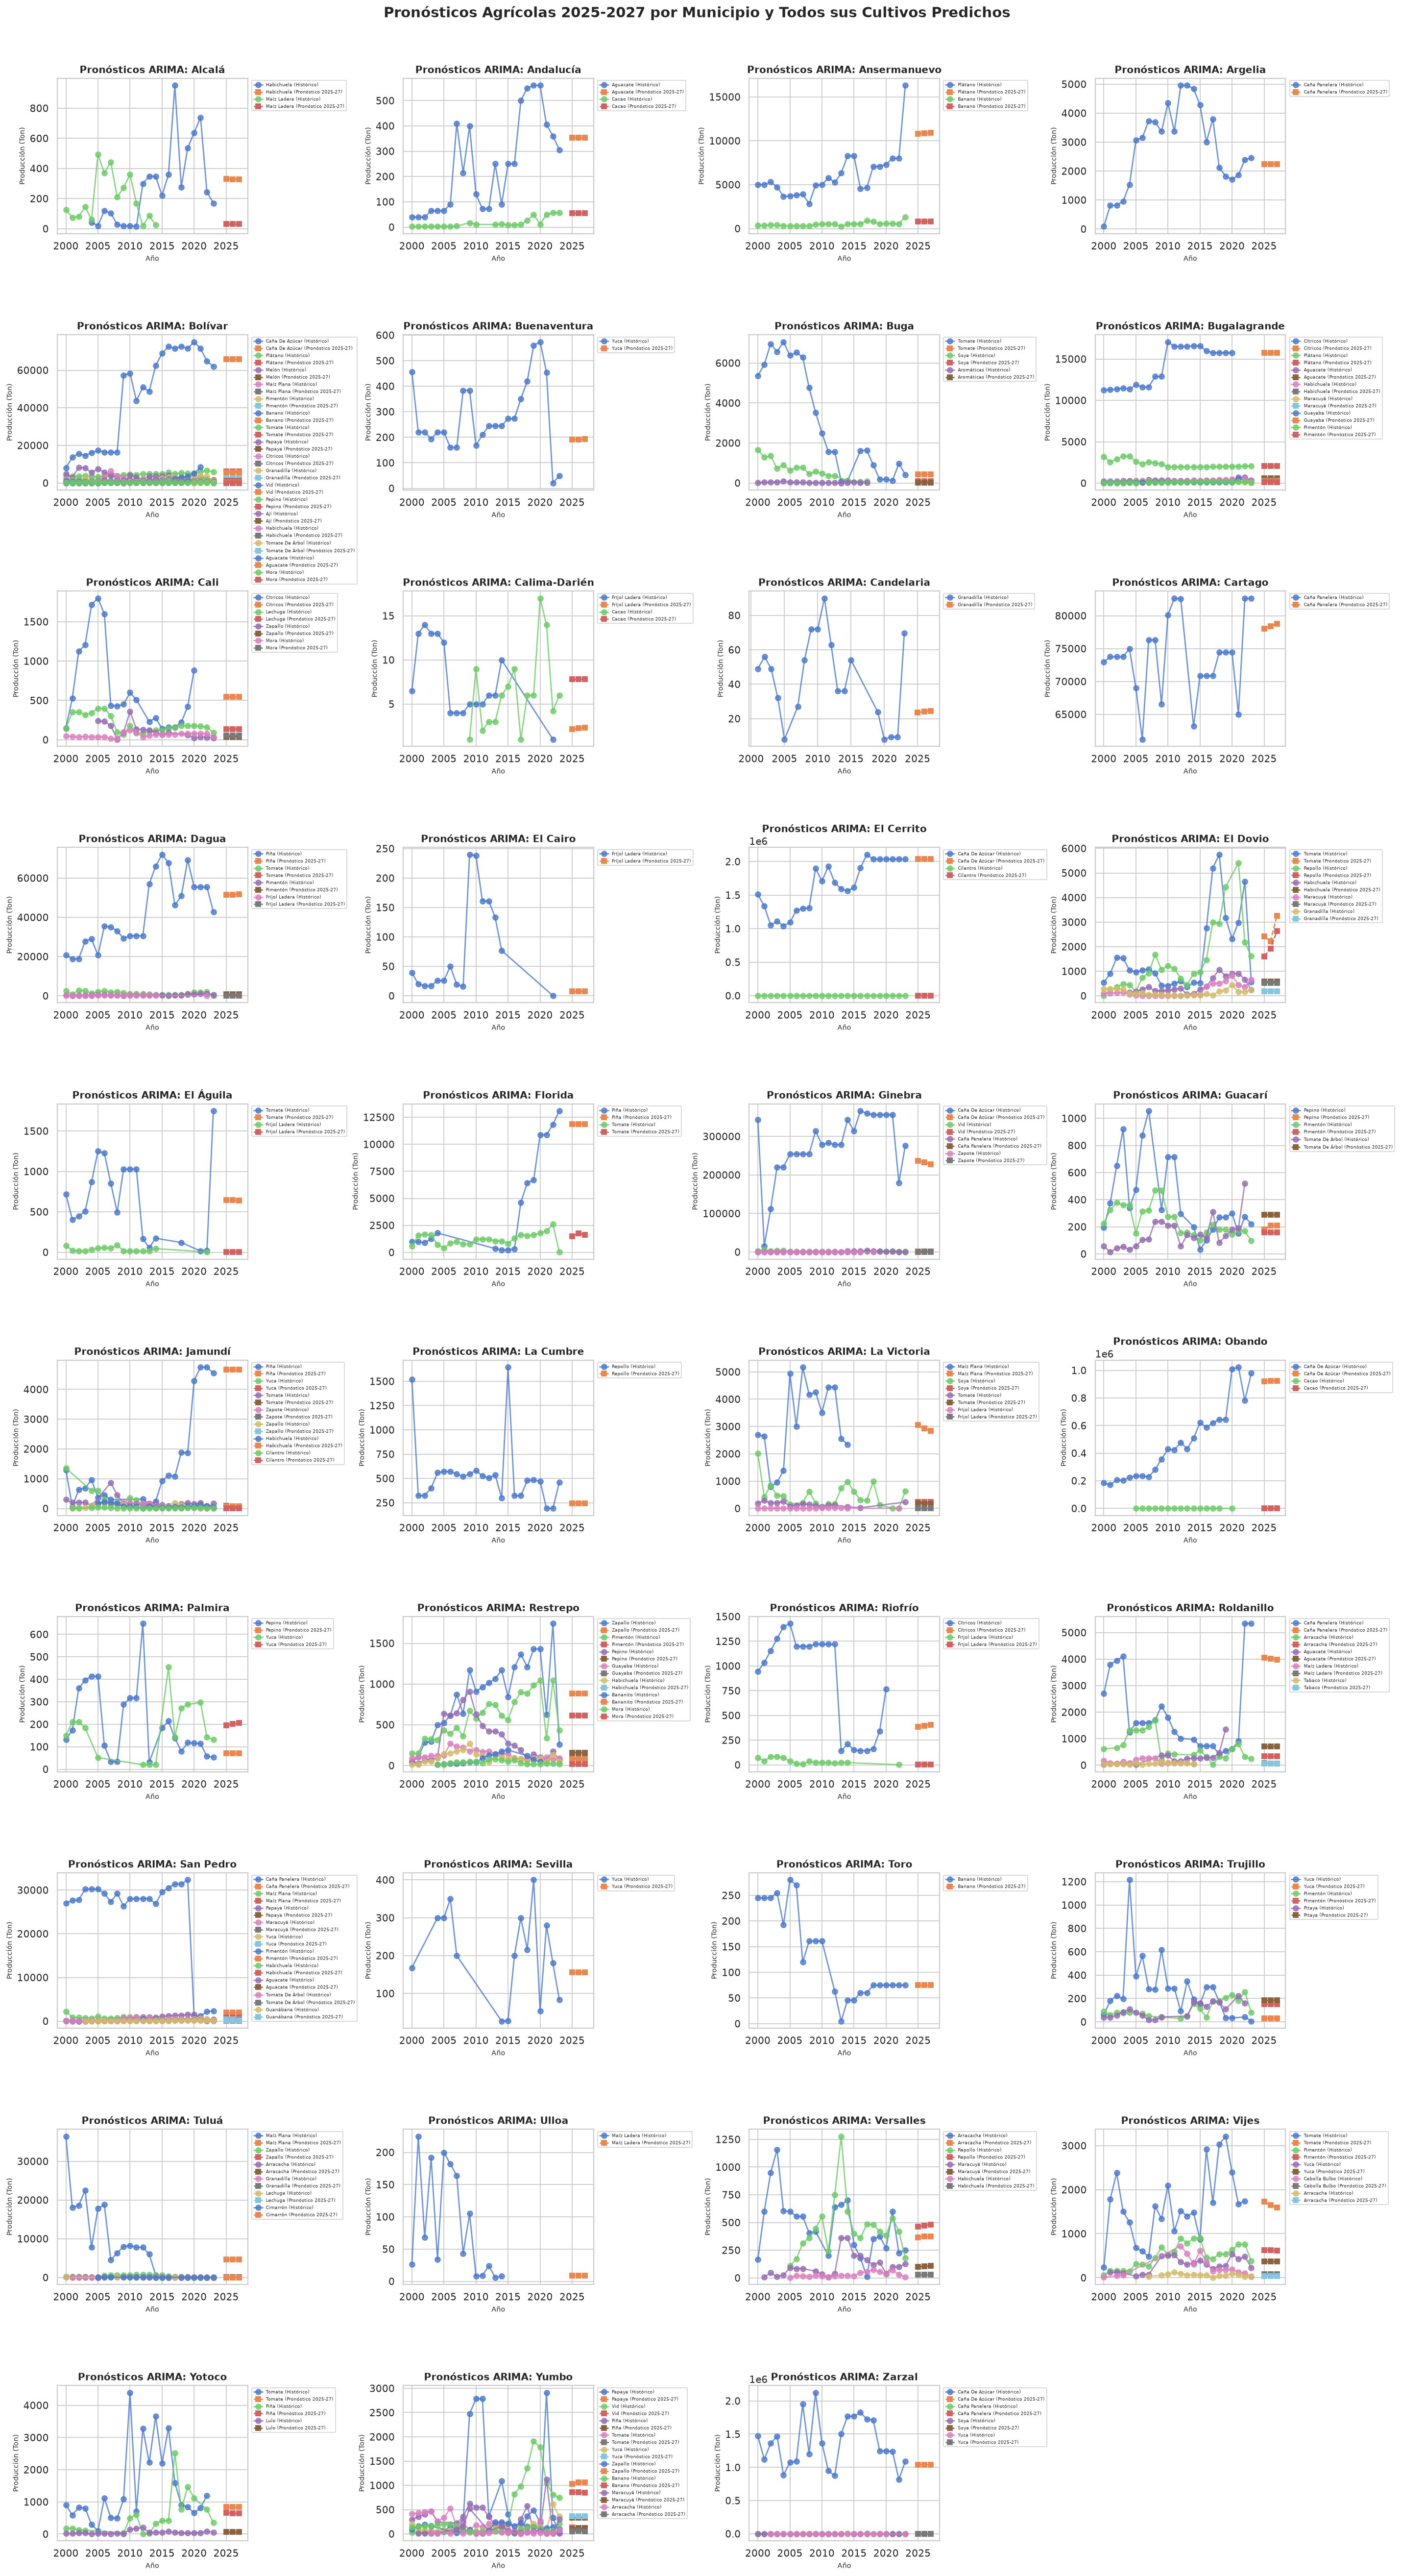

=== TABLA COMPLETA DE PRONÓSTICOS A 3 AÑOS (2025 - 2027) PARA TODAS LAS PAREJAS MUNICIPIO - CULTIVO ===


,municipio,cultivo,arima_order,r2_backtesting,anio_pronostico,produccion_predicha_ton,intervalo_inferior_80,intervalo_superior_80
0,El Cerrito,Caña De Azúcar,"ARIMA(0, 1, 0)",1.000000,2025,2.035800e+06,1.804790e+06,2.266810e+06
1,El Cerrito,Caña De Azúcar,"ARIMA(0, 1, 0)",1.000000,2026,2.035800e+06,1.709103e+06,2.362497e+06
2,El Cerrito,Caña De Azúcar,"ARIMA(0, 1, 0)",1.000000,2027,2.035800e+06,1.635679e+06,2.435921e+06
3,Zarzal,Caña De Azúcar,"ARIMAX(1, 0, 0)+Hectáreas",0.994143,2025,1.042193e+06,9.445306e+05,1.139856e+06
4,Zarzal,Caña De Azúcar,"ARIMAX(1, 0, 0)+Hectáreas",0.994143,2026,1.040356e+06,9.419776e+05,1.138735e+06
...,...,...,...,...,...,...,...,...
424,Obando,Cacao,"ARIMAX(1, 0, 0)+Hectáreas",0.829782,2026,5.461385e+00,2.707152e-01,1.065206e+01
425,Obando,Cacao,"ARIMAX(1, 0, 0)+Hectáreas",0.829782,2027,5.355202e+00,3.553544e-02,1.067487e+01
426,Calima-Darién,Cacao,"ARIMAX(0, 0, 0)+Hectáreas",0.963949,2025,7.842125e+00,5.965153e+00,9.719097e+00
427,Calima-Darién,Cacao,"ARIMAX(0, 0, 0)+Hectáreas",0.963949,2026,7.842125e+00,5.965153e+00,9.719097e+00


In [6]:
img1 = get_path('notebooks/figures/arima_plus_top_pronosticos_3_anos.png')
if not img1.exists():
    img1 = get_path('figures/arima_plus_top_pronosticos_3_anos.png')
if img1.exists():
    display(Image(filename=str(img1)))

img2 = get_path('notebooks/figures/arima_plus_grid_pronosticos_municipios.png')
if not img2.exists():
    img2 = get_path('figures/arima_plus_grid_pronosticos_municipios.png')
if img2.exists():
    display(Image(filename=str(img2)))

print("=== TABLA COMPLETA DE PRONÓSTICOS A 3 AÑOS (2025 - 2027) PARA TODAS LAS PAREJAS MUNICIPIO - CULTIVO ===")
display(df_fc)